# **시계열 데이터**

# **12-1. datetime 오브젝트**

datetime 라이브러리: 날짜와 시간을 처리
- 날과룰 처리하는 date 오브젝트
- 시간을 처리하는 time 오브젝트
- 날짜와 시간을 모두 처 티하는 datetime 오브젝트

In [2]:
from datetime import datetime

In [3]:
now1=datetime.now()
print(now1)

2026-09-20 14:55:57.356087


In [4]:
now2=datetime.today()
print(now2)

2026-09-20 14:55:57.884674


In [5]:
t1=datetime.now()
t2=datetime(1970,1,1)
t3=datetime(1970,12,12,13,24,34)

print(t1)
print(t2)
print(t3)

2026-09-20 14:55:58.393129
1970-01-01 00:00:00
1970-12-12 13:24:34


- now 메서드는 밀리 초 단위까지 구함

datetime 오브젝트를 사용하는 이유 중 하나는 시간 계산이 가능


In [6]:
diff1 = t1-t2
print(diff1)
print(type(diff1))

20716 days, 14:55:58.393129
<class 'datetime.timedelta'>


In [7]:
diff2 = t2 - t1
print(diff2)
print(type(diff2))

-20717 days, 9:04:01.606871
<class 'datetime.timedelta'>


# datetime 오브젝트로 변환하기 - to_datetime 메서드

문자열을 datetime 오브젝트로 번환하기

1. ebola 대이터 집합 불러오기

In [59]:
import pandas as pd
import os
ebola = pd.read_csv('/content/country_timeseries.csv')

2. 문자열로 저장된 Date 열이 있음을 확인

In [ ]:
print(ebola.info( ))

3. to_datetime 메서드를 사용 - Date 열의 자료형을 datetime 오브젝트로 번환 가능
- Date 열의 자료형을 datetime
브젝트로 변환한 다음 ebola 데이터프레임에 새로운 열로 추가

In [60]:
ebola['date_dt'] = pd.to_datetime(ebola['Date'])
print(ebola.info( ))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

4.  시간 형식 지정자(%d, %m, %y)와 기호(/, -)를 적절히 조합하여 format 인자에 전달하면 그 형식에 맞게 정러된 datetime 오브
젝트를 얻을 수 있음

In [62]:
test_df1 = pd.DataFrame({'order_day':['01/01/15', '02/01/15', '03/01/15']})

test_df1['date_dt1'] = pd.to_datetime(test_df1['order_day'],format='%d/%m/%y')
test_df1['date_dt2'] = pd.to_datetime(test_df1['order_day'],format='%d/%m/%y')
test_df1['date_dt3'] = pd.to_datetime(test_df1['order_day'],format='%d/%m/%y')

print(test_df1)

  order_day   date_dt1   date_dt2   date_dt3
0  01/01/15 2015-01-01 2015-01-01 2015-01-01
1  02/01/15 2015-01-02 2015-01-02 2015-01-02
2  03/01/15 2015-01-03 2015-01-03 2015-01-03


In [64]:
test_df2 = pd.DataFrame({'order_day':['01-01-15', '02-01-15', '03-01-15']})
test_df2 ['date_dt'] = pd.to_datetime(test_df2['order_day'], format='%d-%m-%y')

print(test_df2)

  order_day    date_dt
0  01-01-15 2015-01-01
1  02-01-15 2015-01-02
2  03-01-15 2015-01-03


# 시간 형식 지정자

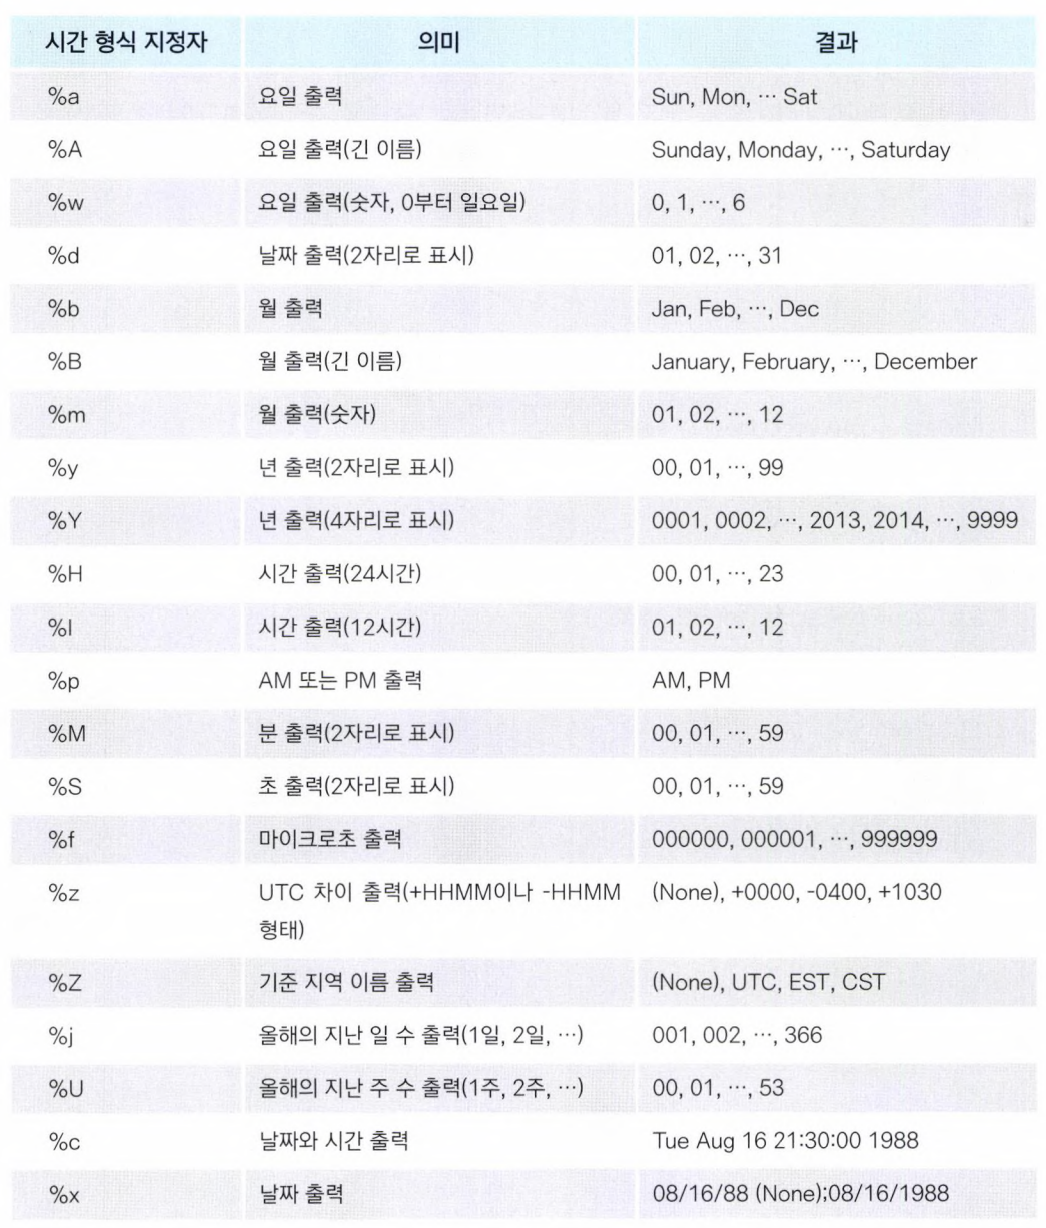

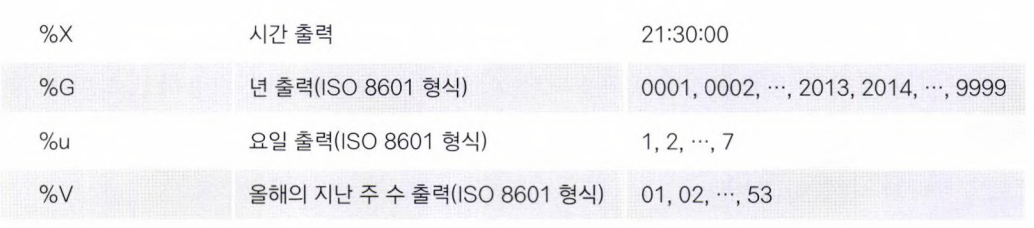

strftime 메서드와 시간 형식 지정자 를 이용하여 시계열 데이터 잘라내기

In [12]:
now = datetime.now( )
print(now)

2026-09-20 15:33:17.898298


In [14]:
nowDate = now.strftime('%Y-%m-%d')
print(nowDate)

2026-09-20


In [15]:
nowTime = now.strftime('%H:%M:%S')
print(nowTime)

15:33:17


In [16]:
nowDatetime = now.strftime('%Y-%m-%d %H:%M:%S')
print(nowDatetime)


2026-09-20 15:33:17


# datetime 오브젝트로 변환하기 一 read.csv 메서드

read_csv 메서드의 parse_dates 인자에 datetime 오브젝트로 변환하고자 하는 열의 이름을 전달하여 데이터 집합 불러오기

In [66]:
ebolal = pd.read_csv('/content/country_timeseries.csv', parse_dates=['Date'])
print(ebolal.info( ))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    datetime64[ns]
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

# datetime 오브젝트에서 날짜 정보 추출하기

1. 문자열로 저장된 날짜를 시리즈에 담아 datetime 오브젝트로 변환

In [18]:
date_series = pd.Series(['2018-05-16','2018-05-17','2018-05-18'])
d1 = pd.to_datetime(date_series)
print(d1)

0   2018-05-16
1   2018-05-17
2   2018-05-18
dtype: datetime64[ns]


2. datetime 오브젝트(d1)의 year, month, day 속성을 이용 - 년, 월, 일 정보 바로 추출 가능

In [19]:
print(d1[0].year)

print(d1[0].month)

print(d1[0].day)

2018
5
16


# dt 접근자 사용하기
dt 접근자를 사용하면 datetime 속성이나 메서드를 사용하여 시계열 데이터 처리 가능

# dt 접근자로 시계열 데이터 정리하기

1. ebola 데이터 집합을 불러온 다음 Date 열을 datetime 오브젝트로 번환하여 새로운 열(date_dt)로 추가

In [67]:
ebola = pd.read_csv('/content/country_timeseries.csv')
ebola['date_dt'] = pd.to_datetime(ebola['Date'])

2. dt 접근자를 사용하지 않고 인덱스가 3인 데이터의 년, 월, 일 데이터 추출

In [68]:
print(ebola[['Date', 'date_dt']].head( ))

         Date    date_dt
0    1/5/2015 2015-01-05
1    1/4/2015 2015-01-04
2    1/3/2015 2015-01-03
3    1/2/2015 2015-01-02
4  12/31/2014 2014-12-31


In [69]:
print(ebola['date_dt'][3].year)

print(ebola['date_dt'][3].month)

print(ebola['date_dt'][3].day)

2015
1
2


3. dt 접근자로 date_dt 열에 한 번에 접근한 다음 year 속성을 이용하여 연
도값 추출 & 추출한 연도값은 ebola 데이터프레임의 새로운 열(year)로 추가

In [70]:
ebola['year'] = ebola['date_dt'].dt.year
print(ebola[['Date', 'date_dt', 'year']].head( ))

         Date    date_dt  year
0    1/5/2015 2015-01-05  2015
1    1/4/2015 2015-01-04  2015
2    1/3/2015 2015-01-03  2015
3    1/2/2015 2015-01-02  2015
4  12/31/2014 2014-12-31  2014


4. 월, 일 데이터를 한 번에 추출해서 새로운 열(month, day)로 추가

In [71]:
ebola['month'], ebola['day'] = (ebola['date_dt'].dt.month, ebola['date_dt'].dt.day)
print(ebola[['Date', 'date_dt', 'year', 'month', 'day']].head( ))

         Date    date_dt  year  month  day
0    1/5/2015 2015-01-05  2015      1    5
1    1/4/2015 2015-01-04  2015      1    4
2    1/3/2015 2015-01-03  2015      1    3
3    1/2/2015 2015-01-02  2015      1    2
4  12/31/2014 2014-12-31  2014     12   31


5. date_dt 열은 datetime 오브젝트이
고 나머지는 정수형임을 확인

In [72]:
print(ebola.info( ))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

# **12-2 사례별 시계열 데이터 계산하기**

# 에볼라 최초 발병일 게산하기

1. ebola 데이터 프레임 확인
- 데이터가 시간 역순으로 정렬 -> 마지막부터 살펴보아야 시간 순으로 데이터를 살펴볼 수 있음

In [74]:
print(ebola.iloc[-5:,:5])

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117  3/27/2014    5         103.0            8.0                6.0
118  3/26/2014    4          86.0            NaN                NaN
119  3/25/2014    3          86.0            NaN                NaN
120  3/24/2014    2          86.0            NaN                NaN
121  3/22/2014    0          49.0            NaN                NaN


2. min 메서드를 사용하여 에볼라의 최초 발병 일 찾기

In [75]:
print(ebola['date_dt'].min( ))
print(type(ebola['date_dt'].min( )))

2014-03-22 00:00:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


3. 에볼라 진행 정도 구하기 - Date 열에서 에볼라의 최초 발병일을 빼기

In [76]:
ebola['outbreak_d'] = ebola['date_dt'] - ebola['date_dt'].min()
print(ebola[['Date','Date','outbreak_d']].head())

         Date        Date outbreak_d
0    1/5/2015    1/5/2015   289 days
1    1/4/2015    1/4/2015   288 days
2    1/3/2015    1/3/2015   287 days
3    1/2/2015    1/2/2015   286 days
4  12/31/2014  12/31/2014   284 days


# 파산한 은행의 개수 게산하기

1. 파산한 은행 데이터 집합 불러오기 - banks 데이터프레임의 앞부분을 살펴보면 Closing Date, Updated Date 열의 데이터 자료형이 시계열 데이터임을 알 수 있음

In [78]:
banks = pd.read_csv('/content/banklist.csv')
print(banks.head())

                                           Bank Name                City  ST  \
0                                Fayette County Bank          Saint Elmo  IL   
1  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee  WI   
2                                     First NBC Bank         New Orleans  LA   
3                                      Proficio Bank  Cottonwood Heights  UT   
4                      Seaway Bank and Trust Company             Chicago  IL   

    CERT                Acquiring Institution Closing Date Updated Date  
0   1802            United Fidelity Bank, fsb    26-May-17    26-Jul-17  
1  30003  First-Citizens Bank & Trust Company     5-May-17    26-Jul-17  
2  58302                         Whitney Bank    28-Apr-17    26-Jul-17  
3  35495                    Cache Valley Bank     3-Mar-17    18-May-17  
4  19328                  State Bank of Texas    27-Jan-17    18-May-17  


2. read_csv 메서드의 parse_dates 속성을 이용하여 문자열로 저장된 두 열을 datetime 오브젝트로 변환하여 불러오기 - Closing Date, Updated Date 열의 데이터 자료형: 문자열

In [82]:
banks_no_dates = pd.read_csv('/content/banklist.csv')
print(banks_no_dates.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              553 non-null    object
 1   City                   553 non-null    object
 2   ST                     553 non-null    object
 3   CERT                   553 non-null    int64 
 4   Acquiring Institution  553 non-null    object
 5   Closing Date           553 non-null    object
 6   Updated Date           553 non-null    object
dtypes: int64(1), object(6)
memory usage: 30.4+ KB
None


In [84]:
banks = pd.read_csv('/content/banklist.csv',parse_dates=[5, 6])
print(banks.info( ))

/tmp/ipykernel_2291/4090829271.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('/content/banklist.csv',parse_dates=[5, 6])
/tmp/ipykernel_2291/4090829271.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('/content/banklist.csv',parse_dates=[5, 6])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Bank Name              553 non-null    object        
 1   City                   553 non-null    object        
 2   ST                     553 non-null    object        
 3   CERT                   553 non-null    int64         
 4   Acquiring Institution  553 non-null    object        
 5   Closing Date           553 non-null    datetime64[ns]
 6   Updated Date           553 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 30.4+ KB
None


3. dt 접근자와 quarter 속성을 이용해 은행이 파산한 분기 알기 - dt 접근자와 year, quarter 속성을 이용하여 은행이 파산한 연도, 분기를 새로운 열로 추가

In [85]:
banks['closing_quarter'], banks['closing_year']=(banks['Closing Date'].
dt.quarter, banks['Closing Date'].dt.year)

print(banks.head())

                                           Bank Name                City  ST  \
0                                Fayette County Bank          Saint Elmo  IL   
1  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee  WI   
2                                     First NBC Bank         New Orleans  LA   
3                                      Proficio Bank  Cottonwood Heights  UT   
4                      Seaway Bank and Trust Company             Chicago  IL   

    CERT                Acquiring Institution Closing Date Updated Date  \
0   1802            United Fidelity Bank, fsb   2017-05-26   2017-07-26   
1  30003  First-Citizens Bank & Trust Company   2017-05-05   2017-07-26   
2  58302                         Whitney Bank   2017-04-28   2017-07-26   
3  35495                    Cache Valley Bank   2017-03-03   2017-05-18   
4  19328                  State Bank of Texas   2017-01-27   2017-05-18   

   closing_quarter  closing_year  
0                2          2017 

4.  grouby 메서드를 사용하면
연도별로 파산한 은행의 개수 구하기

In [88]:
closing_year = banks.groupby(['closing_year']).size( )
print(closing_year)

closing_year
2000      2
2001      4
2002     11
2003      3
2004      4
2007      3
2008     25
2009    140
2010    157
2011     92
2012     51
2013     24
2014     18
2015      8
2016      5
2017      6
dtype: int64


5. 각 연도별, 분기별로 파산한 은행의 개수도 알아보기

In [89]:
closing_year_q = banks.groupby(['closing_year', 'closing_quarter']).size( )
print(closing_year_q)

closing_year  closing_quarter
2000          4                   2
2001          1                   1
              2                   1
              3                   2
2002          1                   6
              2                   2
              3                   1
              4                   2
2003          1                   1
              2                   1
              4                   1
2004          1                   3
              2                   1
2007          1                   1
              3                   1
              4                   1
2008          1                   2
              2                   2
              3                   9
              4                  12
2009          1                  21
              2                  24
              3                  50
              4                  45
2010          1                  41
              2                  45
              3                  4

6. 그래프로 나타내기

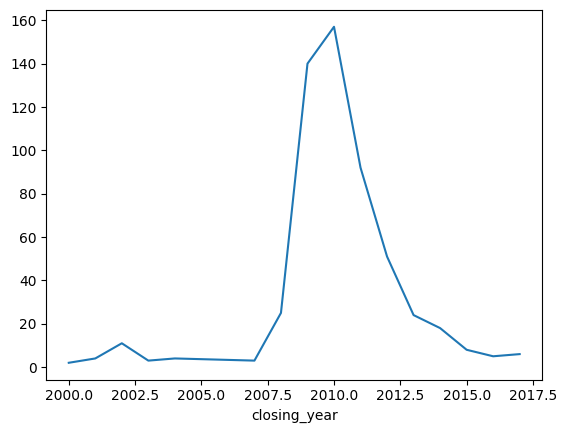

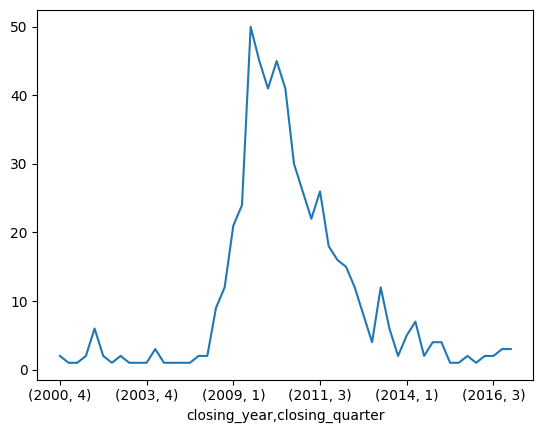

In [91]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots( )
ax= closing_year.plot()
plt.show()

fig, ax=plt.subplots()
ax=closing_year_q.plot()
plt.show()

# 테슬라 주식 데이터로 시간 계산하기

In [21]:
pip install pandas-datareader

1. get_data_quanal 메서드에 TSLA라는 문자열을 전달 -> 테슬라의 주식 데이
터 내려받기 -> to_csv 메서드를 사용하여 data 폴더 안에 'tesIa_stock_quandl.csv' 라는 이 름으로 저장

In [46]:
pd.core.common.is_list_like = pd.api.types.is_list_like
import pandas_datareader as pdr

# tesla에는 데이프레임이 저장됩니다
#tesla = pdr.get_data_quandl('TSLA', api_key = '받은 key')

# tesla에 저장된 데이터프레임을 파일로 저장합니다
#tesla.to_csv('../data/tesla_stock_quandl.csv')
tesla = pd.read_csv('/content/tesla_stock_quandl.csv')

2. tesla 데이터프레임의 Date 열은 문자열로 저장 - datetime 오브젝트로
자료형을 변환해야 시간 계산 가능

In [30]:
print(tesla.head( ))

         Date    Open    High     Low   Close      Volume  ExDividend  \
0  2018-03-27  304.00  304.27  277.18  279.18  13696168.0         0.0   
1  2018-03-26  307.34  307.59  291.36  304.18   8324639.0         0.0   
2  2018-03-23  311.25  311.61  300.45  301.54   6600538.0         0.0   
3  2018-03-22  313.89  318.82  308.18  309.10   4914307.0         0.0   
4  2018-03-21  310.25  322.44  310.19  316.53   5927881.0         0.0   

   SplitRatio  AdjOpen  AdjHigh  AdjLow  AdjClose   AdjVolume  
0         1.0   304.00   304.27  277.18    279.18  13696168.0  
1         1.0   307.34   307.59  291.36    304.18   8324639.0  
2         1.0   311.25   311.61  300.45    301.54   6600538.0  
3         1.0   313.89   318.82  308.18    309.10   4914307.0  
4         1.0   310.25   322.44  310.19    316.53   5927881.0  


3. Date 열을 Datetime 형으로 변환 -> read_csv 메서드로 데이터 집합(tesla_
quandl.csv)을 불러올 때 parse_dates 인자에 Date열 전달

In [47]:
tesla = pd.read_csv('/content/tesla_stock_quandl.csv', parse_dates=[0])
print(tesla.info( ))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1949 entries, 0 to 1948
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1949 non-null   datetime64[ns]
 1   Open        1949 non-null   float64       
 2   High        1949 non-null   float64       
 3   Low         1949 non-null   float64       
 4   Close       1949 non-null   float64       
 5   Volume      1949 non-null   float64       
 6   ExDividend  1949 non-null   float64       
 7   SplitRatio  1949 non-null   float64       
 8   AdjOpen     1949 non-null   float64       
 9   AdjHigh     1949 non-null   float64       
 10  AdjLow      1949 non-null   float64       
 11  AdjClose    1949 non-null   float64       
 12  AdjVolume   1949 non-null   float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 198.1 KB
None


4. dt 접근자 사용

In [48]:
print(tesla.loc[(tesla.Date.dt.year == 2010) & (tesla.Date.dt.month == 6)])

           Date   Open     High    Low  Close      Volume  ExDividend  \
1947 2010-06-30  25.79  30.4192  23.30  23.83  17187100.0         0.0   
1948 2010-06-29  19.00  25.0000  17.54  23.89  18766300.0         0.0   

      SplitRatio  AdjOpen  AdjHigh  AdjLow  AdjClose   AdjVolume  
1947         1.0    25.79  30.4192   23.30     23.83  17187100.0  
1948         1.0    19.00  25.0000   17.54     23.89  18766300.0  


# datetime 오브젝트와 인덱스 - DatetimeIndex

- datetime 오브젝트를 데이터프레임의 인덱스로 설정하면 원하는 시간의 데이터를 바로 추출 가능

# datetime 오브젝트를 인덱스로 설정해 데이터 추출하기


1. Date 열을 tesla 데이터프레임의 인덱스로 지정

In [49]:
tesla.index = tesla['Date']
print(tesla.index)

DatetimeIndex(['2018-03-27', '2018-03-26', '2018-03-23', '2018-03-22',
               '2018-03-21', '2018-03-20', '2018-03-19', '2018-03-16',
               '2018-03-15', '2018-03-14',
               ...
               '2010-07-13', '2010-07-12', '2010-07-09', '2010-07-08',
               '2010-07-07', '2010-07-06', '2010-07-02', '2010-07-01',
               '2010-06-30', '2010-06-29'],
              dtype='datetime64[ns]', name='Date', length=1949, freq=None)


2, 3. datetime 오브젝트를 인덱스로 지정하면 원하는 시간의 데이터 바로 추출 가능

In [50]:
tesla.index = tesla['Date']
print(tesla.loc['2015'].iloc[:5, :5])

                 Date    Open     High       Low   Close
Date                                                    
2015-12-31 2015-12-31  238.51  243.450  238.3700  240.01
2015-12-30 2015-12-30  236.60  243.634  235.6707  238.09
2015-12-29 2015-12-29  230.06  237.720  229.5470  237.19
2015-12-28 2015-12-28  231.49  231.980  225.5400  228.95
2015-12-24 2015-12-24  230.56  231.880  228.2800  230.57


In [51]:
# 1. Date 열을 문자열에서 'datetime' 타입으로 먼저 변환
tesla['Date'] = pd.to_datetime(tesla['Date'])

# 2. datetime 형태가 된 Date 열을 인덱스로 지정
tesla.set_index('Date', inplace=True)

# 3. 책의 3번 코드 실행
print(tesla.loc['2010-06'].iloc[:, :5])

             Open     High    Low  Close      Volume
Date                                                
2010-06-30  25.79  30.4192  23.30  23.83  17187100.0
2010-06-29  19.00  25.0000  17.54  23.89  18766300.0


# 시간 간격과 인덱스 一 Timedeltaindex

시간 간격을 인덱스로 지정해 데이터 추출하기

1. Date 열에서 Date 열의 최솟값(2010-06-29) 빼기 - ref_date 열로 추가

In [53]:
# 1. 인덱스로 빠져있는 Date를 다시 일반 컬럼으로 되돌리기
tesla = tesla.reset_index()

# 2. Date 열이 datetime 형태인지 확인/변환
tesla['Date'] = pd.to_datetime(tesla['Date'])

# 3. 책 코드 실행 (시간 간격 계산)
tesla['ref_date'] = tesla['Date'] - tesla['Date'].min()
print(tesla.head())

        Date    Open    High     Low   Close      Volume  ExDividend  \
0 2018-03-27  304.00  304.27  277.18  279.18  13696168.0         0.0   
1 2018-03-26  307.34  307.59  291.36  304.18   8324639.0         0.0   
2 2018-03-23  311.25  311.61  300.45  301.54   6600538.0         0.0   
3 2018-03-22  313.89  318.82  308.18  309.10   4914307.0         0.0   
4 2018-03-21  310.25  322.44  310.19  316.53   5927881.0         0.0   

   SplitRatio  AdjOpen  AdjHigh  AdjLow  AdjClose   AdjVolume  ref_date  
0         1.0   304.00   304.27  277.18    279.18  13696168.0 2828 days  
1         1.0   307.34   307.59  291.36    304.18   8324639.0 2827 days  
2         1.0   311.25   311.61  300.45    301.54   6600538.0 2824 days  
3         1.0   313.89   318.82  308.18    309.10   4914307.0 2823 days  
4         1.0   310.25   322.44  310.19    316.53   5927881.0 2822 days  


2. 시간 간격을(ref_date) 이용해 데이터 추출

In [54]:
tesla.index = tesla['ref_date']
print(tesla.iloc[:5,:5])

                Date    Open    High     Low   Close
ref_date                                            
2828 days 2018-03-27  304.00  304.27  277.18  279.18
2827 days 2018-03-26  307.34  307.59  291.36  304.18
2824 days 2018-03-23  311.25  311.61  300.45  301.54
2823 days 2018-03-22  313.89  318.82  308.18  309.10
2822 days 2018-03-21  310.25  322.44  310.19  316.53


3. 데이터를 수집한 이후 최초 5일의 데이터 추출

In [55]:
print(tesla['5 days':].iloc[:5,:5])

               Date   Open     High    Low  Close
ref_date                                         
3 days   2010-07-02  23.00  23.1000  18.71  19.20
2 days   2010-07-01  25.00  25.9200  20.27  21.96
1 days   2010-06-30  25.79  30.4192  23.30  23.83
0 days   2010-06-29  19.00  25.0000  17.54  23.89


# 시간 범위와 인덱스

데이터를 수집하지 못한 날 발생 가능 -> 특정 일에 누라고디 데이터도 포함시켜 데이터 살펴보기

# 시간 범위 생성해 인덱스로 지정하기

1. 에볼라 데이터 살펴보기(테슬라는 누락된 데이터 없음)

In [93]:
ebola = pd.read_csv('/content/country_timeseries.csv')

print(ebola.iloc[:5,:5])

print(ebola.iloc[-5:,:5]) # 뒤 쪽 데이터

         Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0    1/5/2015  289        2776.0            NaN            10030.0
1    1/4/2015  288        2775.0            NaN             9780.0
2    1/3/2015  287        2769.0         8166.0             9722.0
3    1/2/2015  286           NaN         8157.0                NaN
4  12/31/2014  284        2730.0         8115.0             9633.0
          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117  3/27/2014    5         103.0            8.0                6.0
118  3/26/2014    4          86.0            NaN                NaN
119  3/25/2014    3          86.0            NaN                NaN
120  3/24/2014    2          86.0            NaN                NaN
121  3/22/2014    0          49.0            NaN                NaN


3. date_range 메서드 이용 - 2014년 12웓 31일 ~ 2015년 1월 5일 사이의 시간 인덱스(DatetimeIndex) 생성

In [57]:
head_range = pd.date_range(start='2014-12-31', end='2015-01-05')
print(head_range)

DatetimeIndex(['2014-12-31', '2015-01-01', '2015-01-02', '2015-01-03',
               '2015-01-04', '2015-01-05'],
              dtype='datetime64[ns]', freq='D')


4. Date 열을 인덱스로 지정한 다음 과정 3에
서 생성한 시간 범위를 인덱스로 지정(오류 방지)

In [94]:
ebola_5 = ebola.head( )
ebola_5.index = ebola_5['Date']
ebola_5.reindex(head_range)
print(ebola_5.iloc[:5, :5])

                  Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
Date                                                                       
1/5/2015      1/5/2015  289        2776.0            NaN            10030.0
1/4/2015      1/4/2015  288        2775.0            NaN             9780.0
1/3/2015      1/3/2015  287        2769.0         8166.0             9722.0
1/2/2015      1/2/2015  286           NaN         8157.0                NaN
12/31/2014  12/31/2014  284        2730.0         8115.0             9633.0


# 시간 범위 수정하고 데이터 밀어내기 - shift 메서드

# 에볼라의 확산 속도 비교하기

1. ebola 데이터프레임의 Date 열을 인스로 지정해 x축을 Date 열로, y축을 사망자 수로 지정하여 그래프 그리기

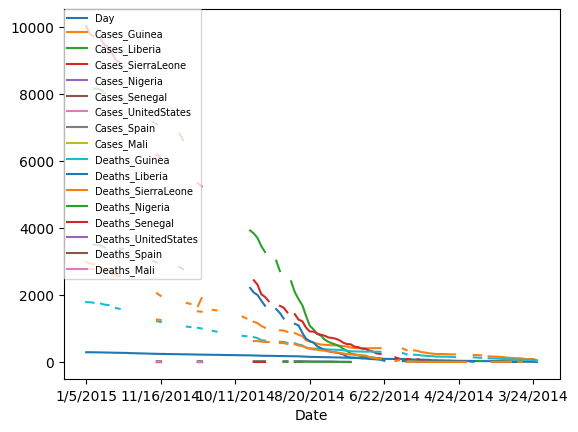

In [96]:
import matplotlib.pyplot as plt

ebola.index = ebola['Date']
fig,ax = plt.subplots( )
ax = ebola.iloc[0:,1:].plot(ax=ax)
ax.legend(fontsize=7, loc=2, borderaxespad=0.)

plt.show()

2. 각 나라의 발병일을 가장 처음 에볼라가 발병한 Guinea와 동일한 위치로 옮겨 나라별 에볼라의 확산 속도 비교

In [97]:
ebola_sub = ebola[['Day','Cases_Guinea','Cases_Liberia']]
print(ebola_sub.tail(10))

           Day  Cases_Guinea  Cases_Liberia
Date                                       
4/4/2014    13         143.0           18.0
4/1/2014    10         127.0            8.0
3/31/2014    9         122.0            8.0
3/29/2014    7         112.0            7.0
3/28/2014    6         112.0            3.0
3/27/2014    5         103.0            8.0
3/26/2014    4          86.0            NaN
3/25/2014    3          86.0            NaN
3/24/2014    2          86.0            NaN
3/22/2014    0          49.0            NaN


3. Date 열의 자료형을 datetime 오브젝트로 변환하여 ebola 데이터프레임 다시 생성 ( 중간에 아예 날짜가 없는 데이터(2015년 1월 1일)도 포함시켜 확산 속도 비교)

In [98]:
ebola = pd.read_csv('country_timeseries.csv', parse_dates=['Date'])
print(ebola.head( ).iloc[:,:5])

        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0


4.  Date 열을 인덱스로 지정한 다음 ebola 데이터프레임의 Date 열의 최댓값과 최솟값으로 시간 빔위를 생성하여 new index에 저장 = 날짜가 아예 없던 데이터의 인덱스도 지정 가능

In [99]:
ebola.index=ebola['Date']
new_idx = pd.date_range(ebola.index.min( ), ebola.index.max( ))

5. 시간 순서를 맞추기 위해 reversed 메서드를 사용하여 인텍스를 반대로 뒤집기

In [100]:
print(new_idx)

new_idx=reversed(new_idx)

DatetimeIndex(['2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31',
               ...
               '2014-12-27', '2014-12-28', '2014-12-29', '2014-12-30',
               '2014-12-31', '2015-01-01', '2015-01-02', '2015-01-03',
               '2015-01-04', '2015-01-05'],
              dtype='datetime64[ns]', length=290, freq='D')


6. reindex 메서드룰 사용하여 새로 생성한 인덱스(new idx)를 새로운 인덱스로 지정 = 아예 없던 날짜 추가(2015년 1월 1일) & 그래프 생성

In [101]:
ebola = ebola.reindex(new_idx)

print(ebola.head( ).iloc[:,:5])

print(ebola.tail( ).iloc[:, :5])

                 Date    Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
Date                                                                        
2015-01-05 2015-01-05  289.0        2776.0            NaN            10030.0
2015-01-04 2015-01-04  288.0        2775.0            NaN             9780.0
2015-01-03 2015-01-03  287.0        2769.0         8166.0             9722.0
2015-01-02 2015-01-02  286.0           NaN         8157.0                NaN
2015-01-01        NaT    NaN           NaN            NaN                NaN
                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
Date                                                                      
2014-03-26 2014-03-26  4.0          86.0            NaN                NaN
2014-03-25 2014-03-25  3.0          86.0            NaN                NaN
2014-03-24 2014-03-24  2.0          86.0            NaN                NaN
2014-03-23        NaT  NaN           NaN            NaN                NaN
2014-03-22 

7. 각 나라의 에볼라 발병일 옮기기

In [102]:
last_valid = ebola.apply(pd.Series.last_valid_index) # 가장 오래된 데이터 가져옴
print(last_valid)

first_valid = ebola.apply(pd.Series.first_valid_index) # 가장 최근 데이터 가져옴
print(first_valid)

Date                  2014-03-22
Day                   2014-03-22
Cases_Guinea          2014-03-22
Cases_Liberia         2014-03-27
Cases_SierraLeone     2014-03-27
Cases_Nigeria         2014-07-23
Cases_Senegal         2014-08-31
Cases_UnitedStates    2014-10-01
Cases_Spain           2014-10-08
Cases_Mali            2014-10-22
Deaths_Guinea         2014-03-22
Deaths_Liberia        2014-03-27
Deaths_SierraLeone    2014-03-27
Deaths_Nigeria        2014-07-23
Deaths_Senegal        2014-09-07
Deaths_UnitedStates   2014-10-01
Deaths_Spain          2014-10-08
Deaths_Mali           2014-10-22
dtype: datetime64[ns]
Date                  2015-01-05
Day                   2015-01-05
Cases_Guinea          2015-01-05
Cases_Liberia         2015-01-03
Cases_SierraLeone     2015-01-05
Cases_Nigeria         2014-12-07
Cases_Senegal         2014-12-07
Cases_UnitedStates    2014-12-07
Cases_Spain           2014-12-07
Cases_Mali            2014-12-07
Deaths_Guinea         2015-01-05
Deaths_Liberia       

8. 각 나라의 에볼라 발병일을 동일한 출발선으로 옮기기 - 에볼라가 처음 발병한 날에서 각 나라의 에볼라 발병일을 뺀 만큼 옮기기

In [103]:
earliest_date = ebola.index.min( )
print(earliest_date)

shift_values=last_valid-earliest_date
print(shift_values)

2014-03-22 00:00:00
Date                    0 days
Day                     0 days
Cases_Guinea            0 days
Cases_Liberia           5 days
Cases_SierraLeone       5 days
Cases_Nigeria         123 days
Cases_Senegal         162 days
Cases_UnitedStates    193 days
Cases_Spain           200 days
Cases_Mali            214 days
Deaths_Guinea           0 days
Deaths_Liberia          5 days
Deaths_SierraLeone      5 days
Deaths_Nigeria        123 days
Deaths_Senegal        169 days
Deaths_UnitedStates   193 days
Deaths_Spain          200 days
Deaths_Mali           214 days
dtype: timedelta64[ns]


9. shift 메서드를 사용하여 모든 열의 값을 shift_values 값만큼 옮기기

In [104]:
ebola_dict={}
for idx, col in enumerate(ebola):
  d=shift_values[idx].days
  shifted = ebola[col].shift(d)
  ebola_dict[col]=shifted

/tmp/ipykernel_2291/3142257925.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  d=shift_values[idx].days


10. DataFrame 메서드를 사용하여 ebola_ dict의 값을 데이터프레임으로 변환(원래 딕셔너리 형태로 저장)

In [105]:
ebola_shift = pd.DataFrame(ebola_dict)

11. 에볼라의 최초 발병일(2014- 3-22)을 기준으로 모든 열의 데이터가 옮겨진 상태

In [106]:
print(ebola_shift.tail( ))

                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone  \
Date                                                                         
2014-03-26 2014-03-26  4.0          86.0            8.0                2.0   
2014-03-25 2014-03-25  3.0          86.0            NaN                NaN   
2014-03-24 2014-03-24  2.0          86.0            7.0                NaN   
2014-03-23        NaT  NaN           NaN            3.0                2.0   
2014-03-22 2014-03-22  0.0          49.0            8.0                6.0   

            Cases_Nigeria  Cases_Senegal  Cases_UnitedStates  Cases_Spain  \
Date                                                                        
2014-03-26            1.0            NaN                 1.0          1.0   
2014-03-25            NaN            NaN                 NaN          NaN   
2014-03-24            NaN            NaN                 NaN          NaN   
2014-03-23            NaN            NaN                 NaN        

12. 그래프를 그리기 위한 데이터프레임 만들기  - 인텍스를 Day 열로 지정하고 그래프에 필요 없는 Date, Day 열 삭제

In [107]:
ebola_shift.index = ebola_shift['Day']
ebola_shift = ebola_shift.drop(['Date', 'Day'], axis=1)
print(ebola_shift.tail( ))

     Cases_Guinea  Cases_Liberia  Cases_SierraLeone  Cases_Nigeria  \
Day                                                                  
4.0          86.0            8.0                2.0            1.0   
3.0          86.0            NaN                NaN            NaN   
2.0          86.0            7.0                NaN            NaN   
NaN           NaN            3.0                2.0            NaN   
0.0          49.0            8.0                6.0            0.0   

     Cases_Senegal  Cases_UnitedStates  Cases_Spain  Cases_Mali  \
Day                                                               
4.0            NaN                 1.0          1.0         NaN   
3.0            NaN                 NaN          NaN         NaN   
2.0            NaN                 NaN          NaN         NaN   
NaN            NaN                 NaN          NaN         NaN   
0.0            1.0                 1.0          1.0         1.0   

     Deaths_Guinea  Deaths_Liberia  Dea

13. 위 데이터프레임으로 그래프 그리기

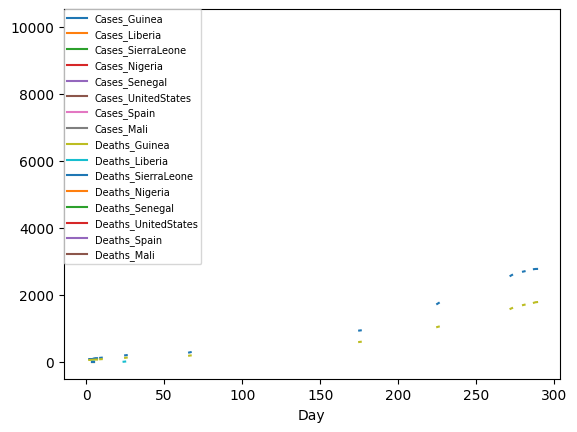

In [109]:
fig, ax = plt.subplots( )
ax = ebola_shift.iloc[:,:].plot(ax=ax)
ax.legend(fontsize=7, loc=2, borderaxespad=0.)
plt.show( )